## Image Preprocessing and Augmentation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
# OS and File management
import os
import zipfile
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras import Model
import keras

In [ ]:
# !wget --no-check-certificate https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip -O /content/cats_and_dogs_filtered.zip

In [5]:
base_dir = r'C:\Users\AmitLuhar\training\dataset\day23\cats_and_dogs_filtered'
train_dir = os.path.join(base_dir,'train')
validation_dir = os.path.join(base_dir,'validation')

In [6]:
train_cats_dir = os.path.join(train_dir,'cats')
train_dogs_dir = os.path.join(train_dir,'dogs')
validation_cats_dir = os.path.join(validation_dir,'cats')
validation_dogs_dir = os.path.join(validation_dir,'dogs')

In [7]:
train_cats_fnames = os.listdir(train_cats_dir)
train_dogs_fnames = os.listdir(train_dogs_dir)


In [8]:
BATCH_SIZE=20
IMG_SHAPE=150

In [23]:

image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range = 0.2,
    height_shift_range=-0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
    )

image_gen_validation = ImageDataGenerator(rescale=1./255)

#Fetch Data and Resize
train_data_gen = image_gen_train.flow_from_directory(
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_SHAPE,IMG_SHAPE),
    batch_size = BATCH_SIZE,
    class_mode = 'binary')

validation_generator = image_gen_validation.flow_from_directory(
    directory=validation_dir,
    shuffle=True,
    target_size=(IMG_SHAPE,IMG_SHAPE),
    batch_size = BATCH_SIZE,
    class_mode = 'binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [24]:
def plotImages(images_arr):
  fig, axes = plt.subplots(1,len(images_arr), figsize=(20,20))
  axes =axes.flatten()
  for img,ax in zip(images_arr,axes):
    ax.imshow(img)
  plt.tight_layout()
  plt.show()

In [25]:
augmented_image = [train_data_gen[0][0][10] for i in range(6)]

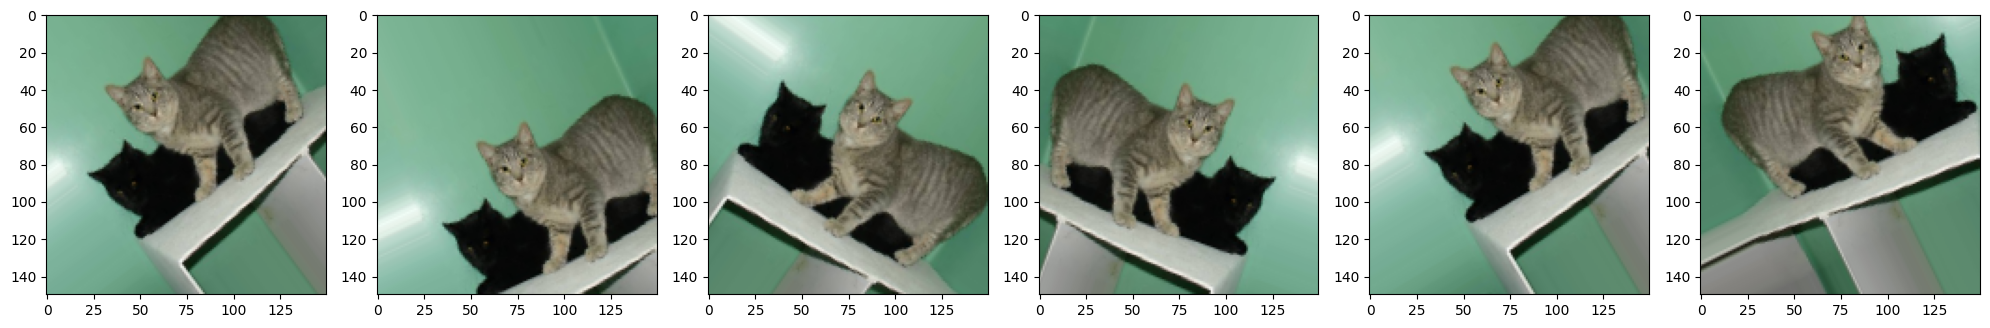

In [26]:
plotImages(augmented_image)

## Transfer Learning

In [27]:
from keras.applications import vgg16

In [28]:
vgg = vgg16.VGG16(include_top= False, weights='imagenet', input_shape=(IMG_SHAPE,IMG_SHAPE,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [29]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, InputLayer

In [36]:
output = vgg.layers[-1].output
output = Flatten()(output)
vgg_model = keras.Model(vgg.input, output)
vgg_model.trainable=False

In [37]:
for layer in vgg_model.layers:
    layer.trainable = False

## Build Custom Classifier

In [39]:
model = keras.Sequential()
model.add(vgg_model)
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_2 (Functional)       │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,942,401 (72.26 MB)

 Trainable params: 4,227,713 (16.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [41]:
from keras.optimizers import RMSprop

In [ ]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(learning_rate=0.001), metrics=['binary_accuracy'])

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=2)

In [ ]:
history = model.fit(
    train_data_gen,
    steps_per_epoch=100,
    epochs=6,
    validation_data=validation_generator,
    callbacks= [callable],
    verbose=2
    )

Epoch 1/6


c:\Users\AmitLuhar\training\env2\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 - 138s - 1s/step - acc: 0.6775 - loss: 0.7555 - val_acc: 0.8420 - val_loss: 0.3427
Epoch 2/6
100/100 - 143s - 1s/step - acc: 0.7830 - loss: 0.4578 - val_acc: 0.7520 - val_loss: 0.4831
Epoch 3/6
100/100 - 138s - 1s/step - acc: 0.8120 - loss: 0.4079 - val_acc: 0.8590 - val_loss: 0.3411
Epoch 4/6
100/100 - 134s - 1s/step - acc: 0.8280 - loss: 0.3834 - val_acc: 0.8650 - val_loss: 0.3024
Epoch 5/6
100/100 - 132s - 1s/step - acc: 0.8325 - loss: 0.3854 - val_acc: 0.8530 - val_loss: 0.2994
Epoch 6/6
100/100 - 140s - 1s/step - acc: 0.8330 - loss: 0.3831 - val_acc: 0.8810 - val_loss: 0.2914


Training Curve

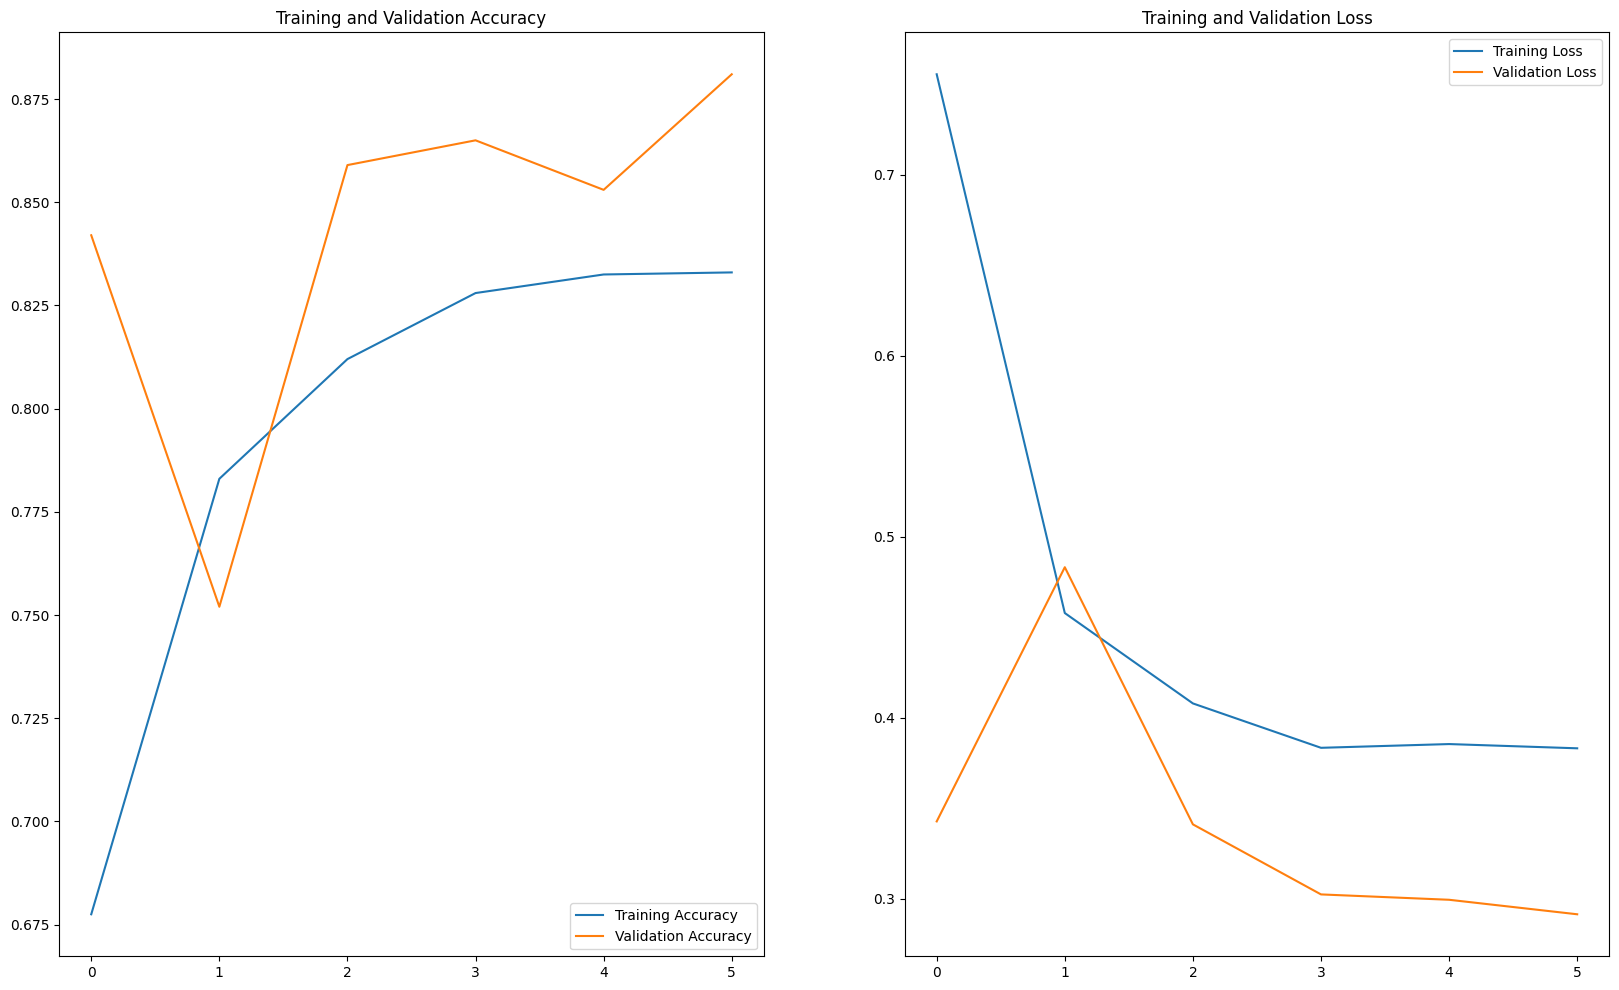

In [45]:
acc = history.history['acc']
val_acc = history.history['val_acc']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 12))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Predictions Display Fun

In [46]:
def cat_or_dog(file):
    img = load_img(file, target_size=(IMG_SHAPE,IMG_SHAPE))
    img = img_to_array(img)
    img = np.expand_dims(img,axis=0)

    probs = model.predict(img)
    if probs[0][0]==1:
        result = 'dog'
    else:
        result = 'cat'
    
    plt.imshow(plt.imread(file))
    plt.show()
    print(f'This is clearly a {result}!')
    return probs

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


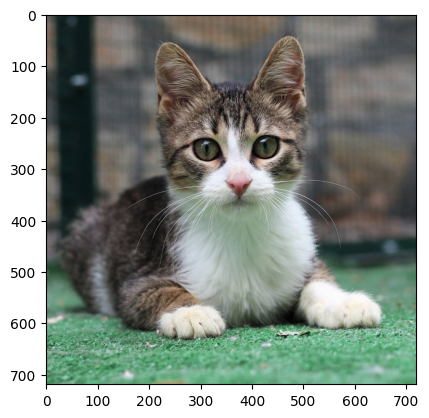

This is clearly a cat!
[[0.]]


In [51]:
file_path = r'C:\Users\AmitLuhar\training\dataset\day24\image.jpeg'
probs = cat_or_dog(file_path)
print(probs)